In [1]:
import numpy as np
import matplotlib.pyplot as plt
from constrained_remez_qsp_fitter import ConstrainedRemezQSPFitter, evaluate_from_coeffs, make_evaluator, visualize_fit

In [5]:
zeta = 1e-3

omega_fit = [
    (0.0, 0.15 * np.pi),
    (0.25 * np.pi, 0.4 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return ((w < 0.19 * np.pi) + 0.0 * (w > 0.2 * np.pi)).astype(float) * (1 - zeta)

def target_prime(w):
    return np.zeros_like(np.asarray(w, dtype=float))

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=100)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]


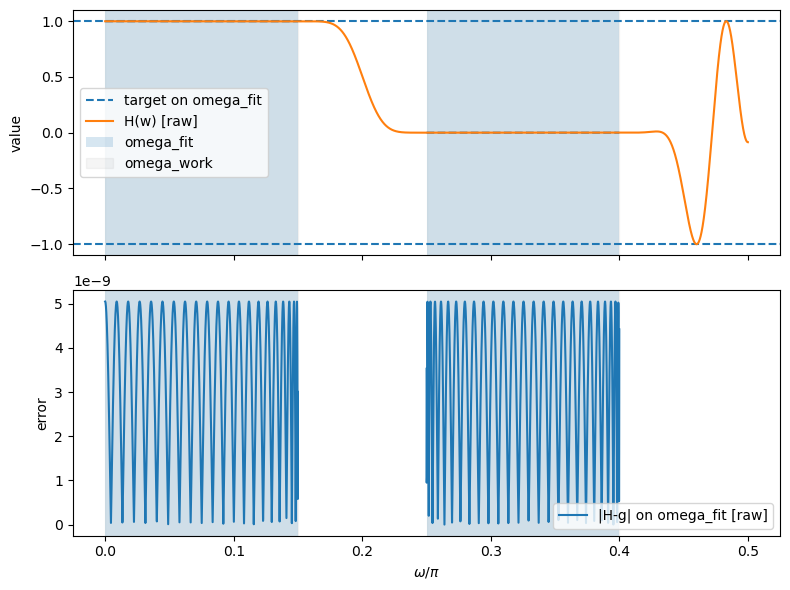

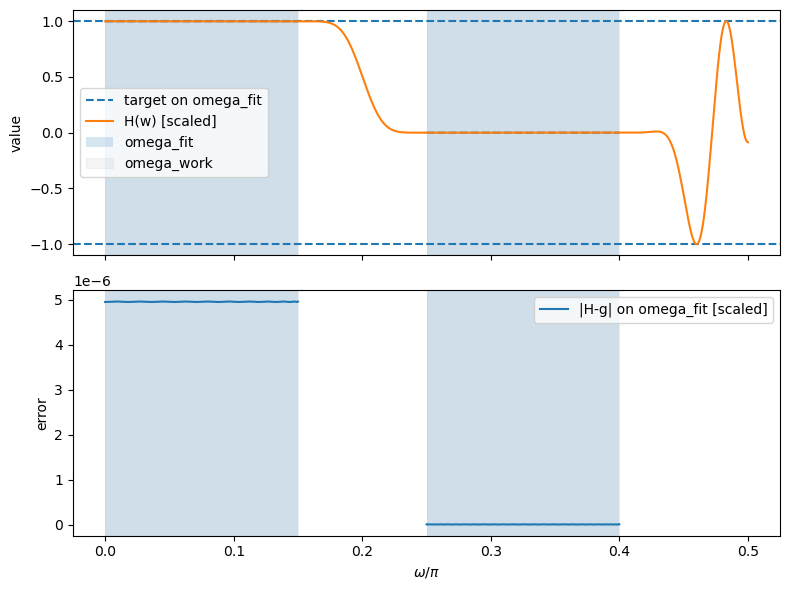

In [6]:
visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

In [7]:
from pprint import pprint

pprint(raw_metrics)
print()
pprint(scaled_metrics)

{'degree': 100,
 'fit_interval_error_0': 5.049799800538324e-09,
 'fit_interval_error_1': 5.049801646284102e-09,
 'kind': 'raw',
 'max_abs_on_domain': 1.000004959649563,
 'max_constraint_violation': 5.651874355194764e-06,
 'max_fit_error_on_fit': 5.049801646284102e-09,
 'max_fit_error_on_work': 5.049801646284102e-09,
 'num_coefficients': 51,
 'raw_max_magnitude': 1.000004959649563,
 'ripple_amplitude': -5.049800046869057e-09,
 'scaling_factor': 1.0,
 'work_interval_error_0': 5.049799800538324e-09,
 'work_interval_error_1': 5.049801646284102e-09}

{'degree': 100,
 'fit_interval_error_0': 4.959715112717866e-06,
 'fit_interval_error_1': 5.049776513610382e-09,
 'kind': 'scaled',
 'max_abs_on_domain': 1.0000000000000004,
 'max_constraint_violation': 6.922213589000137e-07,
 'max_fit_error_on_fit': 4.959715112717866e-06,
 'max_fit_error_on_work': 4.959715112717866e-06,
 'num_coefficients': 51,
 'raw_max_magnitude': 1.000004959649563,
 'ripple_amplitude': -5.049775001754677e-09,
 'scaling_facto

# Heaviside Example used by James
$$g(x) = \left\{\begin{array}{ll} 1 & x < \mu - \delta \\ 0 & x > \mu + \delta  \end{array}\right.$$

James chose $\mu = 0.5, \delta = 0.05$. Two subintervals in $\omega$-space
$$\mathcal{I}_1 = \arccos([0, (\mu - \delta)) = (\arccos(\mu - \delta), \pi/2] \qquad \mathcal{I}_0 = \arccos((\mu + \delta, 1]) = [0, \arccos(\mu + \delta))$$

## Sanity check

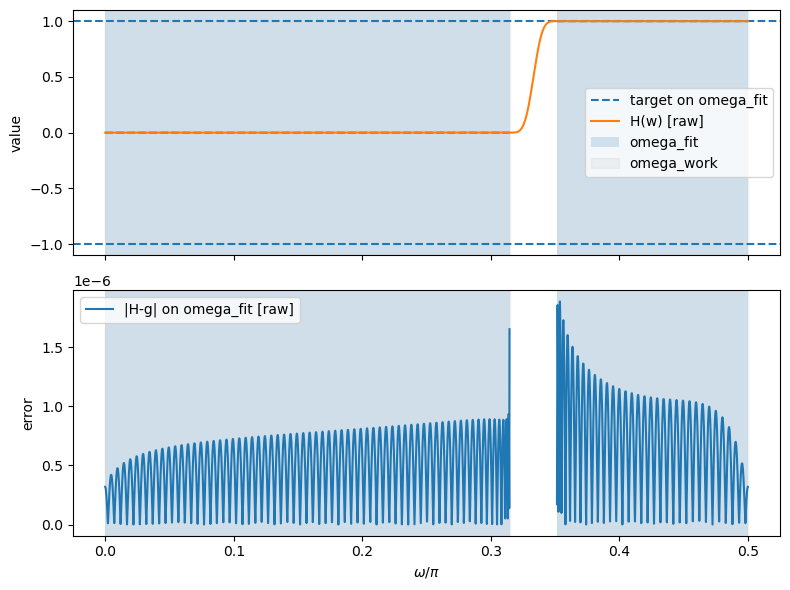

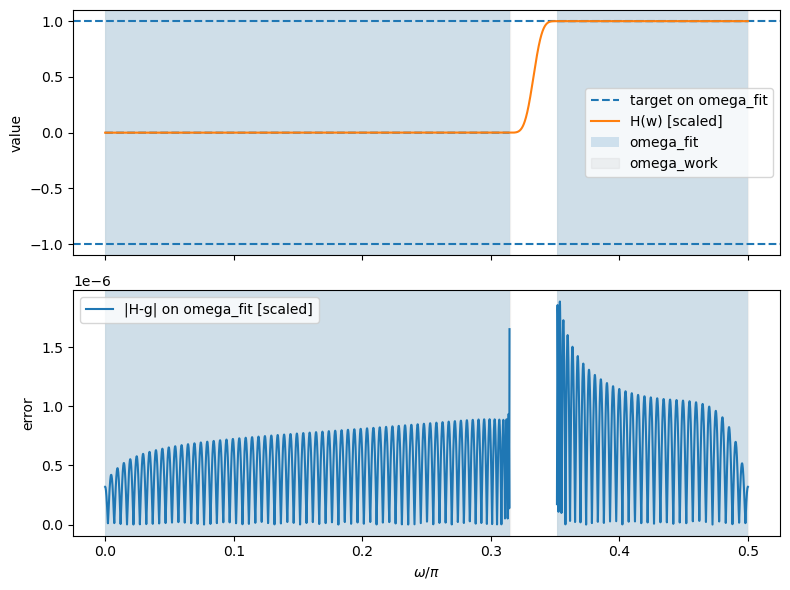

{'degree': 200,
 'fit_interval_error_0': 2.3449820358567575e-06,
 'fit_interval_error_1': 1.8895628218773552e-06,
 'kind': 'raw',
 'max_abs_on_domain': 0.9999918589248995,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 2.3449820358567575e-06,
 'max_fit_error_on_work': 1.9914602321924324e-06,
 'num_coefficients': 101,
 'raw_max_magnitude': 0.9999918589248995,
 'ripple_amplitude': 3.195602010994114e-07,
 'scaling_factor': 1.0,
 'work_interval_error_0': 1.9914602321924324e-06,
 'work_interval_error_1': 1.8893931662544716e-06}

{'degree': 200,
 'fit_interval_error_0': 2.3449820358567575e-06,
 'fit_interval_error_1': 1.8895628218773552e-06,
 'kind': 'scaled',
 'max_abs_on_domain': 0.9999918589248995,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 2.3449820358567575e-06,
 'max_fit_error_on_work': 1.9914602321924324e-06,
 'num_coefficients': 101,
 'raw_max_magnitude': 0.9999918589248995,
 'ripple_amplitude': 3.195602010994114e-07,
 'scaling_factor': 1.0,
 'work_interva

In [19]:
from tqdm import tqdm

mu = 0.5
delta = 0.05
zeta = 1e-5

endpt_I0 = np.arccos(mu + delta)
endpt_I1 = np.arccos(mu - delta)

omega_fit = [
    (0.0, endpt_I0),
    (endpt_I1, 0.5 * np.pi),
]

eps = 1e-4
omega_work = [
    (0.0, endpt_I0 - eps),
    (endpt_I1 + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return (
        0.0 * np.logical_and((w <= endpt_I0), (w >= 0))
        + 
        1.0 * np.logical_and((w >= endpt_I1), (w <= np.pi / 2))
        ).astype(float) * (1 - zeta)

def target_prime(w):
    return np.zeros_like(np.asarray(w, dtype=float))

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=200)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]

visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

pprint(raw_metrics)
print()
pprint(scaled_metrics)

# deg_list = 

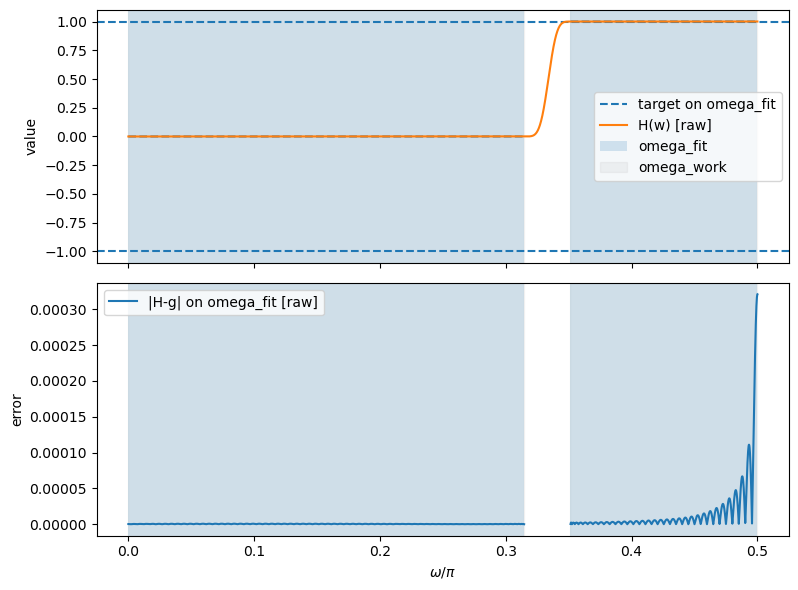

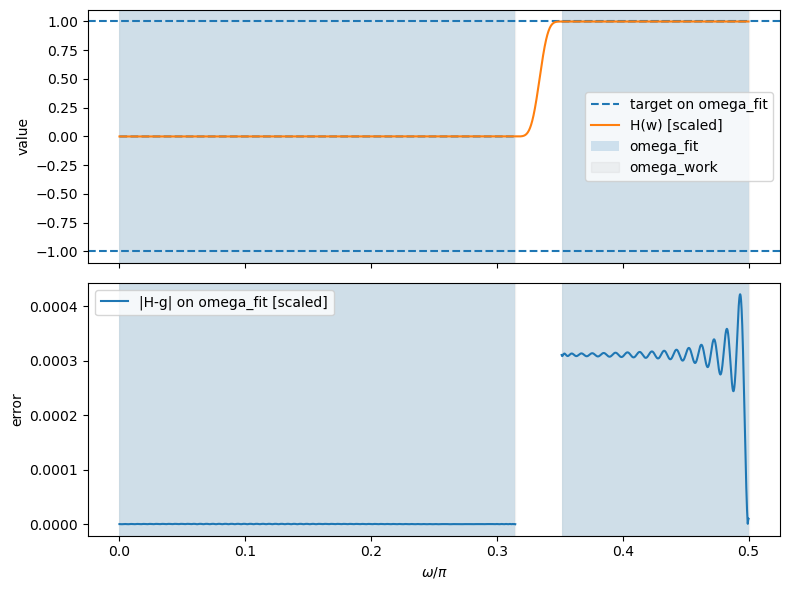

{'degree': 200,
 'fit_interval_error_0': 7.265218502361392e-07,
 'fit_interval_error_1': 0.00032105026602857745,
 'kind': 'raw',
 'max_abs_on_domain': 1.0003110502660286,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 0.00032105026602857745,
 'max_fit_error_on_work': 0.00032105026602857745,
 'num_coefficients': 101,
 'raw_max_magnitude': 1.0003110502660286,
 'ripple_amplitude': -2.5198230469564153e-07,
 'scaling_factor': 1.0,
 'work_interval_error_0': 7.265218502361392e-07,
 'work_interval_error_1': 0.00032105026602857745}

{'degree': 200,
 'fit_interval_error_0': 7.262959356713061e-07,
 'fit_interval_error_1': 0.0004219629436855721,
 'kind': 'scaled',
 'max_abs_on_domain': 0.9999999999999999,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 0.0004219629436855721,
 'max_fit_error_on_work': 0.0004219629436855721,
 'num_coefficients': 101,
 'raw_max_magnitude': 1.0003110502660286,
 'ripple_amplitude': -2.519039499050099e-07,
 'scaling_factor': 1.0003110502660286,
 '

In [20]:
from tqdm import tqdm

mu = 0.5
delta = 0.05
zeta = 1e-5

endpt_I0 = np.arccos(mu + delta)
endpt_I1 = np.arccos(mu - delta)

omega_fit = [
    (0.0, endpt_I0),
    (endpt_I1, 0.5 * np.pi),
]

eps = 1e-4
# omega_work = [
#     (0.0, endpt_I0 - eps),
#     (endpt_I1 + eps, 0.5 * np.pi),
# ]

def target(w):
    w = np.asarray(w)
    return (
        0.0 * np.logical_and((w <= endpt_I0), (w >= 0))
        + 
        1.0 * np.logical_and((w >= endpt_I1), (w <= np.pi / 2))
        ).astype(float) * (1 - zeta)

def target_prime(w):
    return np.zeros_like(np.asarray(w, dtype=float))

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    # omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=200)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]

visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

pprint(raw_metrics)
print()
pprint(scaled_metrics)

# deg_list = 

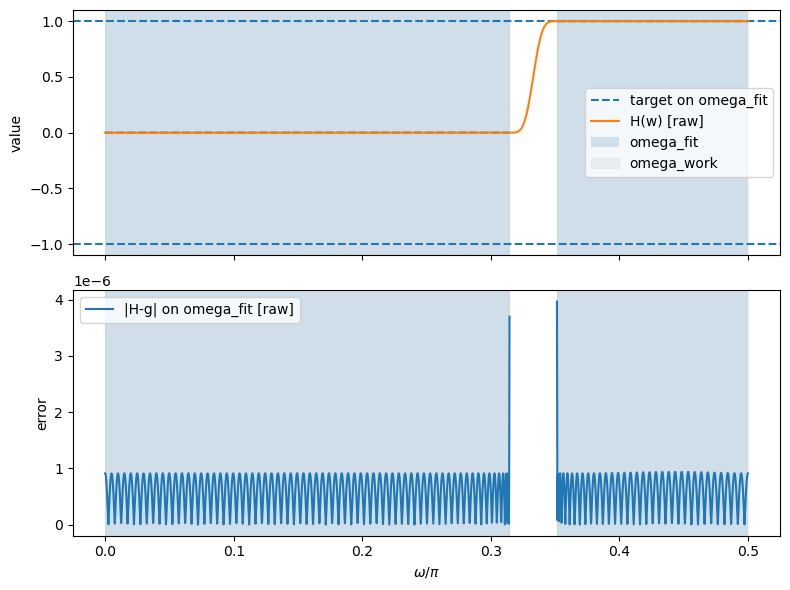

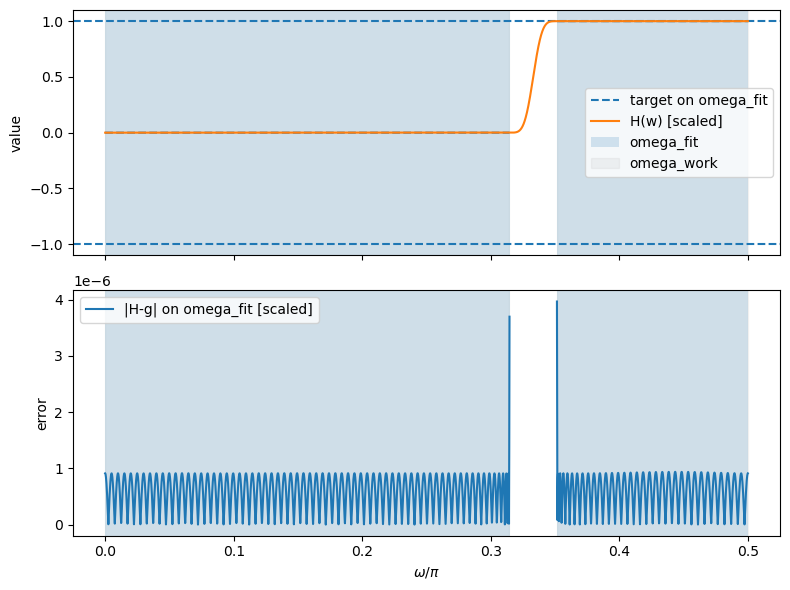

{'degree': 200,
 'fit_interval_error_0': 4.715307883845776e-06,
 'fit_interval_error_1': 4.7077706395448615e-06,
 'kind': 'raw',
 'max_abs_on_domain': 0.999990937981443,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 4.715307883845776e-06,
 'max_fit_error_on_work': 9.381782247741555e-07,
 'num_coefficients': 101,
 'raw_max_magnitude': 0.999990937981443,
 'ripple_amplitude': 9.113152626191029e-07,
 'scaling_factor': 1.0,
 'work_interval_error_0': 9.136118636621227e-07,
 'work_interval_error_1': 9.381782247741555e-07}

{'degree': 200,
 'fit_interval_error_0': 4.715307883845776e-06,
 'fit_interval_error_1': 4.7077706395448615e-06,
 'kind': 'scaled',
 'max_abs_on_domain': 0.999990937981443,
 'max_constraint_violation': 0.0,
 'max_fit_error_on_fit': 4.715307883845776e-06,
 'max_fit_error_on_work': 9.381782247741555e-07,
 'num_coefficients': 101,
 'raw_max_magnitude': 0.999990937981443,
 'ripple_amplitude': 9.113152626191029e-07,
 'scaling_factor': 1.0,
 'work_interval_error_0': 

In [22]:
from tqdm import tqdm

mu = 0.5
delta = 0.05
zeta = 1e-5

endpt_I0 = np.arccos(mu + delta)
endpt_I1 = np.arccos(mu - delta)

omega_fit = [
    (0.0, endpt_I0),
    (endpt_I1, 0.5 * np.pi),
]

eps = 1e-3
omega_work = [
    (0.0, endpt_I0 - eps),
    (endpt_I1 + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return (
        0.0 * np.logical_and((w <= endpt_I0), (w >= 0))
        + 
        1.0 * np.logical_and((w >= endpt_I1), (w <= np.pi / 2))
        ).astype(float) * (1 - zeta)

def target_prime(w):
    return np.zeros_like(np.asarray(w, dtype=float))

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

result = fitter.fit(d=200)

raw_coeffs = result["raw"]["coeffs"]
scaled_coeffs = result["scaled"]["coeffs"]

raw_metrics = result["raw"]["metrics"]
scaled_metrics = result["scaled"]["metrics"]

visualize_fit(fitter, result, which="raw")
visualize_fit(fitter, result, which="scaled")

pprint(raw_metrics)
print()
pprint(scaled_metrics)

# deg_list = 

## Experiments

In [30]:

deg_list = (
        (2 ** np.arange(start = 5, stop = 8.5, step = 0.5)) // 2 * 2
    ).astype(int)

print(deg_list)

err_on_fit = np.zeros(deg_list.shape, dtype = float)
result_fit = {}


mu = 0.5
delta = 0.05
zeta = 1e-5

endpt_I0 = np.arccos(mu + delta)
endpt_I1 = np.arccos(mu - delta)

omega_fit = [
    (0.0, endpt_I0),
    (endpt_I1, 0.5 * np.pi),
]

eps = 1e-4
omega_work = [
    (0.0, endpt_I0 - eps),
    (endpt_I1 + eps, 0.5 * np.pi),
]

def target(w):
    w = np.asarray(w)
    return (
        0.0 * np.logical_and((w <= endpt_I0), (w >= 0))
        + 
        1.0 * np.logical_and((w >= endpt_I1), (w <= np.pi / 2))
        ).astype(float) * (1 - zeta)

def target_prime(w):
    return np.zeros_like(np.asarray(w, dtype=float))

fitter = ConstrainedRemezQSPFitter(
    omega_fit=omega_fit,
    omega_work = omega_work,
    target=target,
    target_prime=target_prime,
    interval_extension=0.0,
)

for j in tqdm(range(deg_list.shape[0])):
    d = deg_list[j]
    result = fitter.fit(d=d)
    err_on_fit[j] = result["scaled"]["metrics"]["max_fit_error_on_fit"]
    result_fit[d] = result


[ 32  44  64  90 128 180 256]


100%|██████████| 7/7 [01:59<00:00, 17.05s/it]


Text(0, 0.5, 'Maximum error vs target')

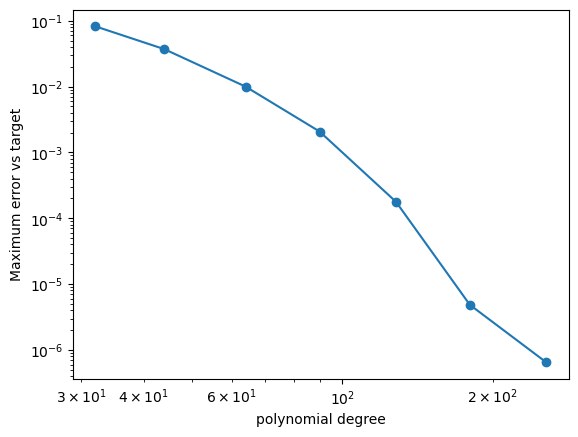

In [31]:
plt.plot(deg_list, err_on_fit, "o-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("Maximum error vs target")

256


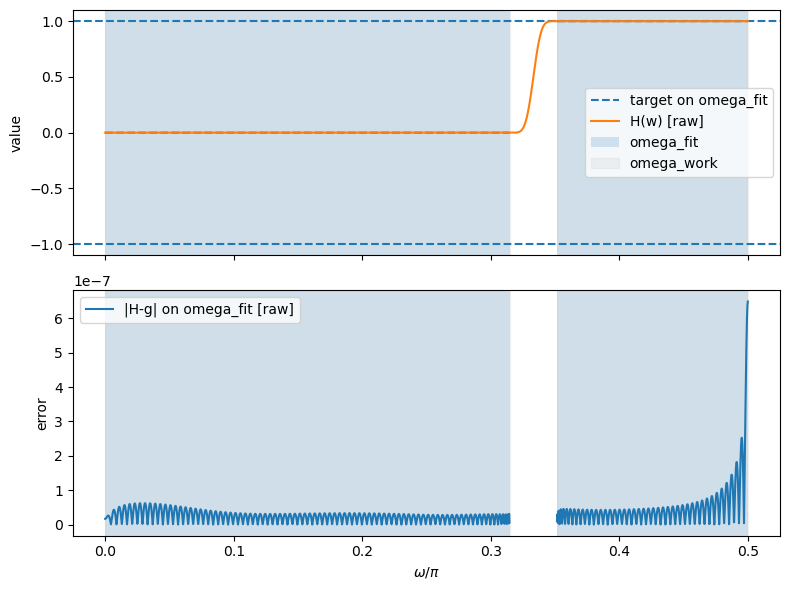

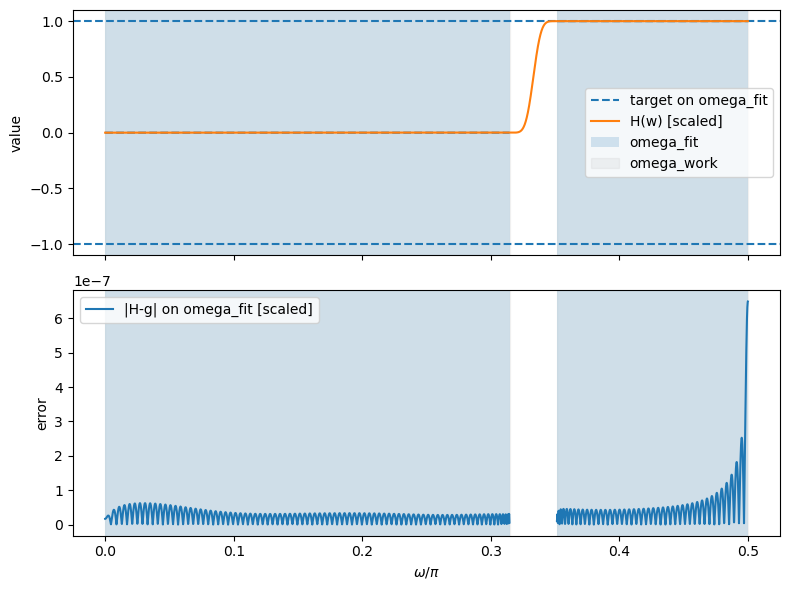

In [33]:
d = deg_list[-1]
print(d)
visualize_fit(fitter, result_fit[d], which="raw")
visualize_fit(fitter, result_fit[d], which="scaled")